Downloading/Installing these libraries into the Colab Python environment.

In [1]:
!pip install -q matminer pymatgen scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 48.5 MB/s eta 0:00:00
   ━━━━━━

Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("compound_band_gap_7500_synthetic.csv")

In [4]:
df.head()

,id,compound,band_gap_eV
0,971,CrGa2Te4,1.886
1,6280,Ga2SiS4,4.284
2,1860,NiHf2Te4,2.076
3,6804,TaCl,0.816
4,6306,FeAlTe2,1.623


In [5]:
df = df.drop("id", axis=1)

In [6]:
print(df.columns)

Index(['compound', 'band_gap_eV'], dtype='object')


In [10]:
df[df["compound"].isna()]

,compound,band_gap_eV
2904,NaN,1.141


In [11]:
df["compound"].isna().sum()

np.int64(1)

In [12]:
df = df.dropna(subset=["compound"]).copy()

In [13]:
print(df["compound"].isna().sum())

0


In [14]:
df["composition"] = df["compound"].apply(
    lambda x: list(Composition(x).elements)
)

In [15]:
df.head()

,compound,band_gap_eV,composition
0,CrGa2Te4,1.886,"[Cr, Ga, Te]"
1,Ga2SiS4,4.284,"[Ga, Si, S]"
2,NiHf2Te4,2.076,"[Ni, Hf, Te]"
3,TaCl,0.816,"[Ta, Cl]"
4,FeAlTe2,1.623,"[Fe, Al, Te]"


Feature Engineering Stage

In [17]:
df["composition"] = df["compound"].apply(Composition)

In [18]:
df["composition"].head()

,composition
0,"(Cr, Ga, Te)"
1,"(Ga, Si, S)"
2,"(Ni, Hf, Te)"
3,"(Ta, Cl)"
4,"(Fe, Al, Te)"


In [19]:
featurizer = ElementProperty.from_preset("magpie")

In [20]:
df = featurizer.featurize_dataframe(
    df,
    col_id="composition"
)

ElementProperty:   0%|          | 0/7499 [00:00<?, ?it/s]

In [21]:
print(df.columns.tolist())

['compound', 'band_gap_eV', 'composition', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row',

In [22]:
print("Number of columns:", df.shape[1])

Number of columns: 135


In [27]:
df.columns = df.columns.str.strip()

In [29]:
print(df.columns.tolist())

['compound', 'band_gap_eV', 'composition', 'MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number', 'MagpieData mean Number', 'MagpieData avg_dev Number', 'MagpieData mode Number', 'MagpieData minimum MendeleevNumber', 'MagpieData maximum MendeleevNumber', 'MagpieData range MendeleevNumber', 'MagpieData mean MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData mode MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData minimum MeltingT', 'MagpieData maximum MeltingT', 'MagpieData range MeltingT', 'MagpieData mean MeltingT', 'MagpieData avg_dev MeltingT', 'MagpieData mode MeltingT', 'MagpieData minimum Column', 'MagpieData maximum Column', 'MagpieData range Column', 'MagpieData mean Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData minimum Row',

In [30]:
y = df["band_gap_eV"]

X = df.drop(columns=["compound", "band_gap_eV", "composition"])

In [31]:
df.head()

,compound,band_gap_eV,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,CrGa2Te4,1.886,"(Cr, Ga, Te)",24.0,52.0,28.0,42.000000,11.428571,52.0,49.0,...,0.000000,0.000000,0.000000,0.0,64.0,229.0,165.0,137.857143,42.204082,152.0
1,Ga2SiS4,4.284,"(Ga, Si, S)",14.0,31.0,17.0,20.000000,6.285714,16.0,74.0,...,0.000000,0.000000,0.000000,0.0,64.0,227.0,163.0,90.714286,38.938776,70.0
2,NiHf2Te4,2.076,"(Ni, Hf, Te)",28.0,72.0,44.0,54.285714,10.122449,52.0,45.0,...,0.595395,0.085056,0.145811,0.0,152.0,225.0,73.0,174.428571,25.632653,152.0
3,TaCl,0.816,"(Ta, Cl)",17.0,73.0,56.0,45.000000,28.000000,17.0,48.0,...,0.000000,0.000000,0.000000,0.0,64.0,229.0,165.0,146.500000,82.500000,64.0
4,FeAlTe2,1.623,"(Fe, Al, Te)",13.0,52.0,39.0,35.750000,16.250000,52.0,55.0,...,2.110663,0.527666,0.791499,0.0,152.0,229.0,77.0,189.500000,37.500000,152.0


Remove constant features

In [32]:
constant_features = X.columns[X.nunique() <= 1]

print("Constant features:")
print(constant_features.tolist())

Constant features:
['MagpieData maximum NsValence', 'MagpieData minimum NsUnfilled', 'MagpieData mode NsUnfilled', 'MagpieData minimum NdUnfilled', 'MagpieData mode NdUnfilled', 'MagpieData minimum NfUnfilled', 'MagpieData maximum NfUnfilled', 'MagpieData range NfUnfilled', 'MagpieData mean NfUnfilled', 'MagpieData avg_dev NfUnfilled', 'MagpieData mode NfUnfilled', 'MagpieData minimum GSmagmom', 'MagpieData mode GSmagmom']


In [33]:
X = X.drop(columns=constant_features)

Remove exactly duplicated features

In [34]:
duplicate_features = X.T.duplicated()

print("Number of duplicate features:", duplicate_features.sum())
print("Duplicate features:")
print(X.columns[duplicate_features].tolist())

Number of duplicate features: 5
Duplicate features:
['MagpieData mode NfValence', 'MagpieData maximum NsUnfilled', 'MagpieData range NsUnfilled', 'MagpieData range NdUnfilled', 'MagpieData range GSmagmom']


In [35]:
X = X.loc[:, ~duplicate_features]

Remove highly correlated features

In [36]:
corr_matrix = X.corr().abs()

In [37]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['MagpieData range MendeleevNumber', 'MagpieData avg_dev MendeleevNumber', 'MagpieData minimum AtomicWeight', 'MagpieData maximum AtomicWeight', 'MagpieData range AtomicWeight', 'MagpieData mean AtomicWeight', 'MagpieData avg_dev AtomicWeight', 'MagpieData mode AtomicWeight', 'MagpieData range MeltingT', 'MagpieData range Column', 'MagpieData avg_dev Column', 'MagpieData mode Column', 'MagpieData mean Row', 'MagpieData mode Row', 'MagpieData mode CovalentRadius', 'MagpieData avg_dev Electronegativity', 'MagpieData range NsValence', 'MagpieData avg_dev NsValence', 'MagpieData maximum NpValence', 'MagpieData range NfValence', 'MagpieData avg_dev NfValence', 'MagpieData mode NValence', 'MagpieData mean NsUnfilled', 'MagpieData avg_dev NsUnfilled', 'MagpieData avg_dev NdUnfilled', 'MagpieData range GSbandgap', 'MagpieData mean GSbandgap', 'MagpieData avg_dev GSbandgap', 'MagpieData avg_dev GSmagmom', 'MagpieData mode SpaceGroupNumber']


In [38]:
X = X.drop(columns=high_corr_features)

In [42]:
df.head()

,band_gap_eV,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,1.886,24.0,52.0,28.0,42.000000,11.428571,52.0,49.0,90.0,41.0,...,0.000000,0.000000,0.000000,0.0,64.0,229.0,165.0,137.857143,42.204082,152.0
1,4.284,14.0,31.0,17.0,20.000000,6.285714,16.0,74.0,88.0,14.0,...,0.000000,0.000000,0.000000,0.0,64.0,227.0,163.0,90.714286,38.938776,70.0
2,2.076,28.0,72.0,44.0,54.285714,10.122449,52.0,45.0,90.0,45.0,...,0.595395,0.085056,0.145811,0.0,152.0,225.0,73.0,174.428571,25.632653,152.0
3,0.816,17.0,73.0,56.0,45.000000,28.000000,17.0,48.0,94.0,46.0,...,0.000000,0.000000,0.000000,0.0,64.0,229.0,165.0,146.500000,82.500000,64.0
4,1.623,13.0,52.0,39.0,35.750000,16.250000,52.0,55.0,90.0,35.0,...,2.110663,0.527666,0.791499,0.0,152.0,229.0,77.0,189.500000,37.500000,152.0


Dropping the redundant and highly correlated features from the dataset

In [43]:
constant_features = df.drop(columns=["band_gap_eV"]).columns[
    df.drop(columns=["band_gap_eV"]).nunique() <= 1
]

df = df.drop(columns=constant_features)

In [44]:
features = df.drop(columns=["band_gap_eV"])

duplicate_features = features.T.duplicated()
duplicate_columns = features.columns[duplicate_features]

df = df.drop(columns=duplicate_columns)

In [45]:
features = df.drop(columns=["band_gap_eV"])

corr_matrix = features.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

df = df.drop(columns=high_corr_features)

In [47]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7499
Columns: 85


In [48]:
X = df.drop(columns=["band_gap_eV"])
y = df["band_gap_eV"]

In [49]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7499, 84)
y shape: (7499,)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5999
Testing samples: 1500


In [52]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [53]:
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [54]:
y_pred = model.predict(X_test)

In [55]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

   Actual  Predicted
0   3.674   3.673563
1   2.628   2.881162
2   2.723   2.902271
3   0.748   0.836327
4   2.792   2.957241
5   4.114   4.144333
6   3.665   3.394112
7   2.835   2.869516
8   3.044   3.376652
9   4.011   4.066904


In [56]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.23935053635963316
RMSE: 0.4825046923815124
R²  : 0.826599420577195


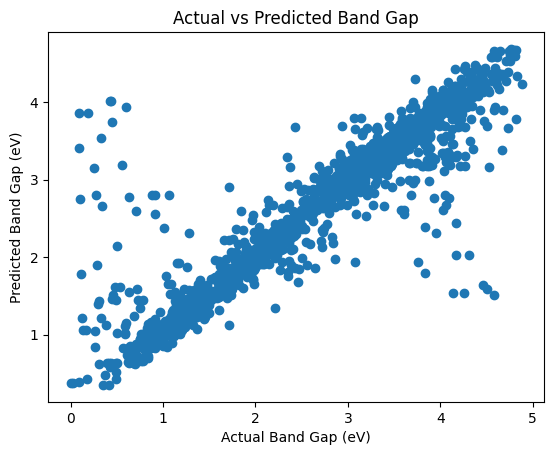

In [57]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Actual vs Predicted Band Gap")

plt.show()